0.06432833516563483
0.04822139805332421
0.04822139805332421


C:\Users\85196\AppData\Local\Temp\ipykernel_15212\2388070196.py:97: UserWarning: FixedFormatter should only be used together with FixedLocator
  cbar.ax.set_yticklabels(ticklabs, fontsize=10)


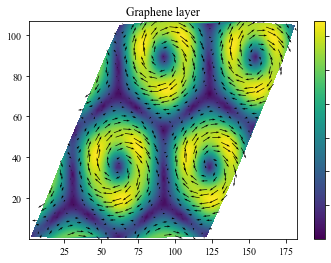

In [99]:
from scipy.interpolate import griddata
import numpy as np
import matplotlib.pyplot as plt

from scipy.interpolate import griddata
import numpy as np
import matplotlib.pyplot as plt

setLatex = False
from mpl_toolkits.axes_grid1 import make_axes_locatable

datadir = '../Ang2.060/Band/FullRelaxed/'

File = datadir+"generate.xyz"
FileI = datadir+"generateInit.xyz"

data = np.genfromtxt(File,skip_header=4)
dataI = np.genfromtxt(FileI,skip_header=4)


#Lvec = np.genfromtxt(datadir+'unitVectors.dat')
#print(Lvec)

xdata = data[::2,1]
ydata = data[::2,2]
zdata = data[::2,3]

xdataI = dataI[::2,1]
ydataI = dataI[::2,2]
zdataI = dataI[::2,3]

cutoff = 10000

xdataC = xdata[np.logical_and(xdata<cutoff, ydata<cutoff)]
ydataC = ydata[np.logical_and(xdata<cutoff, ydata<cutoff)]
zdataC = zdata[np.logical_and(xdata<cutoff, ydata<cutoff)]

xdataIC = xdataI[np.logical_and(xdata<cutoff, ydata<cutoff)]
ydataIC = ydataI[np.logical_and(xdata<cutoff, ydata<cutoff)]
zdataIC = zdataI[np.logical_and(xdata<cutoff, ydata<cutoff)]

xdataC_top = xdataC[zdataIC>17.5]
ydataC_top = ydataC[zdataIC>17.5]
zdataC_top = zdataC[zdataIC>17.5]

xdataIC_top = xdataIC[zdataIC>17.5]
ydataIC_top = ydataIC[zdataIC>17.5]
zdataIC_top = zdataIC[zdataIC>17.5]

displacementx_top = xdataC_top-xdataIC_top
displacementy_top = ydataC_top-ydataIC_top
displacementz_top = zdataC_top-zdataIC_top
displacementxy_top = np.sqrt(((displacementx_top))**2 + ((displacementy_top))**2)
displacementx_top = displacementx_top[(displacementxy_top)<=0.25] 
displacementy_top = displacementy_top[(displacementxy_top)<=0.25] 
xdataC_top = xdataC_top[(displacementxy_top)<=0.25] 
ydataC_top = ydataC_top[(displacementxy_top)<=0.25] 
displacementxy_top = displacementxy_top[(displacementxy_top)<=0.25] 


xdataC_bottom = xdataC[zdataIC==15.825]
ydataC_bottom = ydataC[zdataIC==15.825]
zdataC_bottom = zdataC[zdataIC==15.825]

xdataIC_bottom = xdataIC[zdataIC==15.825]
ydataIC_bottom = ydataIC[zdataIC==15.825]
zdataIC_bottom = zdataIC[zdataIC==15.825]

displacementx_bottom = xdataC_bottom-xdataIC_bottom
displacementy_bottom = ydataC_bottom-ydataIC_bottom
displacementz_bottom = zdataC_bottom-zdataIC_bottom
displacementxy_bottom = np.sqrt(((displacementx_bottom))**2 + ((displacementy_bottom))**2)
displacementx_bottom = displacementx_bottom[(displacementxy_bottom)<=0.25] 
displacementy_bottom = displacementy_bottom[(displacementxy_bottom)<=0.25] 
xdataC_bottom = xdataC_bottom[(displacementxy_bottom)<=0.25] 
ydataC_bottom = ydataC_bottom[(displacementxy_bottom)<=0.25] 
displacementxy_bottom = displacementxy_bottom[(displacementxy_bottom)<=0.25] 

Maxdisplacement_xy_top = max(displacementxy_top)
print(Maxdisplacement_xy_top)
Maxdisplacement_xy_bottom = max(displacementxy_bottom)
print(Maxdisplacement_xy_bottom)

num = 2000
x = np.linspace(min(xdataIC_top),max(xdataIC_top),num)
y = np.linspace(min(ydataIC_top),max(ydataIC_top),num)

print(max(displacementxy_bottom))
cmax = max(displacementxy_bottom)
zdataDXInterpTop=griddata((xdataC_top,ydataC_top),displacementxy_top,(x[None,:], y[:,None]), method='linear')

step = 4
im = plt.quiver(xdataC_top[::step],ydataC_top[::step],displacementx_top[::step],displacementy_top[::step])
im0 = plt.imshow(zdataDXInterpTop,origin="lower",aspect="auto",extent=[min(xdataC_top),max(xdataC_top),min(ydataC_top),max(ydataC_top)])#,vmin=0,vmax=0.07)
cbar = plt.colorbar()
ticklabs = cbar.ax.get_yticklabels()
cbar.ax.set_yticklabels(ticklabs, fontsize=10)


plt.title("Graphene layer")
plt.savefig('Ang2.060.jpg',dpi=400)

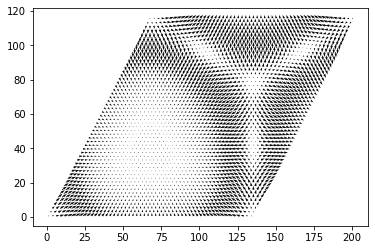

In [21]:
im = plt.quiver(xdataC_bottom,ydataC_bottom,displacementx_bottom,displacementy_bottom)

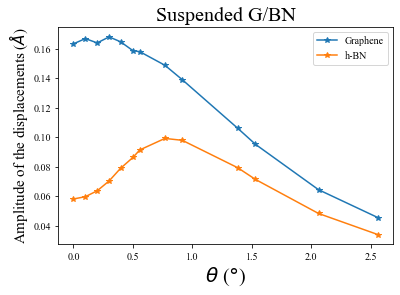

In [10]:
from scipy.interpolate import griddata
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = 'Times New Roman'

Ang = ['0.0','0.1','0.2','0.3','0.396','0.5','0.558','0.769','0.915','1.381','1.530','2.060','2.558']

angle = []
disp_top = []
disp_bottom = []
for ang in Ang:
    datadir = '../Ang'+ang+'/Band/FullRelaxed/'
    
    File = datadir+"generate.xyz"
    FileI = datadir+"generateInit.xyz"
    
    data = np.genfromtxt(File,skip_header=4)
    dataI = np.genfromtxt(FileI,skip_header=4)
    
    xdata = data[::2,1]
    ydata = data[::2,2]
    zdata = data[::2,3]
    
    xdataI = dataI[::2,1]
    ydataI = dataI[::2,2]
    zdataI = dataI[::2,3]
    
    cutoff = 10000
    
    xdataC = xdata[np.logical_and(xdata<cutoff, ydata<cutoff)]
    ydataC = ydata[np.logical_and(xdata<cutoff, ydata<cutoff)]
    zdataC = zdata[np.logical_and(xdata<cutoff, ydata<cutoff)]
    
    xdataIC = xdataI[np.logical_and(xdata<cutoff, ydata<cutoff)]
    ydataIC = ydataI[np.logical_and(xdata<cutoff, ydata<cutoff)]
    zdataIC = zdataI[np.logical_and(xdata<cutoff, ydata<cutoff)]
    
    xdataC_top = xdataC[zdataIC>17.5]
    ydataC_top = ydataC[zdataIC>17.5]
    zdataC_top = zdataC[zdataIC>17.5]
    
    xdataIC_top = xdataIC[zdataIC>17.5]
    ydataIC_top = ydataIC[zdataIC>17.5]
    zdataIC_top = zdataIC[zdataIC>17.5]
    
    displacementx_top = xdataC_top-xdataIC_top
    displacementy_top = ydataC_top-ydataIC_top
    displacementz_top = zdataC_top-zdataIC_top
    displacementxy_top = np.sqrt(((displacementx_top))**2 + ((displacementy_top))**2)
    displacementx_top = displacementx_top[(displacementxy_top)<=0.25] 
    displacementy_top = displacementy_top[(displacementxy_top)<=0.25] 
    xdataC_top = xdataC_top[(displacementxy_top)<=0.25] 
    ydataC_top = ydataC_top[(displacementxy_top)<=0.25] 
    displacementxy_top = displacementxy_top[(displacementxy_top)<=0.25] 
    
    xdataC_bottom = xdataC[zdataIC==15.825]
    ydataC_bottom = ydataC[zdataIC==15.825]
    zdataC_bottom = zdataC[zdataIC==15.825]
    
    xdataIC_bottom = xdataIC[zdataIC==15.825]
    ydataIC_bottom = ydataIC[zdataIC==15.825]
    zdataIC_bottom = zdataIC[zdataIC==15.825]
    
    displacementx_bottom = xdataC_bottom-xdataIC_bottom
    displacementy_bottom = ydataC_bottom-ydataIC_bottom
    displacementz_bottom = zdataC_bottom-zdataIC_bottom
    displacementxy_bottom = np.sqrt(((displacementx_bottom))**2 + ((displacementy_bottom))**2)
    displacementx_bottom = displacementx_bottom[(displacementxy_bottom)<=0.25] 
    displacementy_bottom = displacementy_bottom[(displacementxy_bottom)<=0.25] 
    xdataC_bottom = xdataC_bottom[(displacementxy_bottom)<=0.25] 
    ydataC_bottom = ydataC_bottom[(displacementxy_bottom)<=0.25] 
    displacementxy_bottom = displacementxy_bottom[(displacementxy_bottom)<=0.25] 
    
    Maxdisplacement_xy_top = max(displacementxy_top)
    #rint(ang, Maxdisplacement_xy_top)
    Maxdisplacement_xy_bottom = max(displacementxy_bottom)
    #rint(ang, Maxdisplacement_xy_bottom)
    angle.append(float(ang))
    disp_top.append(Maxdisplacement_xy_top)
    disp_bottom.append(Maxdisplacement_xy_bottom)
    
plt.plot(angle,disp_top,'-*',label='Graphene')
plt.plot(angle,disp_bottom,'-*',label='h-BN')

plt.title('Suspended G/BN',fontsize=20)
#plt.xlabel('$\theta$ ($\degree$)',fontsize=20)
plt.xlabel(''r'$\theta$ ($\degree$)',fontsize=20)
plt.ylabel('Amplitude of the displacements ($\AA$)',fontsize=15)

plt.legend()
plt.savefig('Suspended.jpg',dpi=400)
    #im = plt.quiver(xdataC_top,ydataC_top,displacementx_top,displacementy_top)

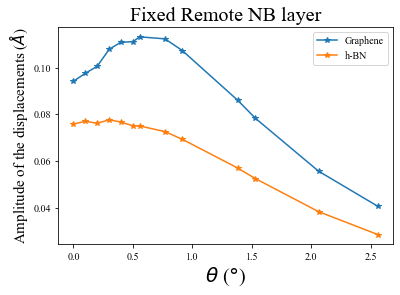

In [11]:
from scipy.interpolate import griddata
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = 'Times New Roman'

Ang = ['0.0','0.1','0.2','0.3','0.396','0.5','0.558','0.769','0.915','1.381','1.530','2.060','2.558']

angle = []
disp_top = []
disp_bottom = []
for ang in Ang:
    datadir = '../Ang'+ang+'/Band/Substrate/'
    
    File = datadir+"generate.xyz"
    FileI = datadir+"generateInit.xyz"
    
    data = np.genfromtxt(File,skip_header=4)
    dataI = np.genfromtxt(FileI,skip_header=4)
    
    xdata = data[::2,1]
    ydata = data[::2,2]
    zdata = data[::2,3]
    
    xdataI = dataI[::2,1]
    ydataI = dataI[::2,2]
    zdataI = dataI[::2,3]
    
    cutoff = 10000
    
    xdataC = xdata[np.logical_and(xdata<cutoff, ydata<cutoff)]
    ydataC = ydata[np.logical_and(xdata<cutoff, ydata<cutoff)]
    zdataC = zdata[np.logical_and(xdata<cutoff, ydata<cutoff)]
    
    xdataIC = xdataI[np.logical_and(xdata<cutoff, ydata<cutoff)]
    ydataIC = ydataI[np.logical_and(xdata<cutoff, ydata<cutoff)]
    zdataIC = zdataI[np.logical_and(xdata<cutoff, ydata<cutoff)]
    
    xdataC_top = xdataC[zdataIC>17.5]
    ydataC_top = ydataC[zdataIC>17.5]
    zdataC_top = zdataC[zdataIC>17.5]
    
    xdataIC_top = xdataIC[zdataIC>17.5]
    ydataIC_top = ydataIC[zdataIC>17.5]
    zdataIC_top = zdataIC[zdataIC>17.5]
    
    displacementx_top = xdataC_top-xdataIC_top
    displacementy_top = ydataC_top-ydataIC_top
    displacementz_top = zdataC_top-zdataIC_top
    displacementxy_top = np.sqrt(((displacementx_top))**2 + ((displacementy_top))**2)
    displacementx_top = displacementx_top[(displacementxy_top)<=0.25] 
    displacementy_top = displacementy_top[(displacementxy_top)<=0.25] 
    xdataC_top = xdataC_top[(displacementxy_top)<=0.25] 
    ydataC_top = ydataC_top[(displacementxy_top)<=0.25] 
    displacementxy_top = displacementxy_top[(displacementxy_top)<=0.25] 
    
    xdataC_bottom = xdataC[zdataIC==15.825]
    ydataC_bottom = ydataC[zdataIC==15.825]
    zdataC_bottom = zdataC[zdataIC==15.825]
    
    xdataIC_bottom = xdataIC[zdataIC==15.825]
    ydataIC_bottom = ydataIC[zdataIC==15.825]
    zdataIC_bottom = zdataIC[zdataIC==15.825]
    
    displacementx_bottom = xdataC_bottom-xdataIC_bottom
    displacementy_bottom = ydataC_bottom-ydataIC_bottom
    displacementz_bottom = zdataC_bottom-zdataIC_bottom
    displacementxy_bottom = np.sqrt(((displacementx_bottom))**2 + ((displacementy_bottom))**2)
    displacementx_bottom = displacementx_bottom[(displacementxy_bottom)<=0.25] 
    displacementy_bottom = displacementy_bottom[(displacementxy_bottom)<=0.25] 
    xdataC_bottom = xdataC_bottom[(displacementxy_bottom)<=0.25] 
    ydataC_bottom = ydataC_bottom[(displacementxy_bottom)<=0.25] 
    displacementxy_bottom = displacementxy_bottom[(displacementxy_bottom)<=0.25] 
    
    Maxdisplacement_xy_top = max(displacementxy_top)
    #rint(ang, Maxdisplacement_xy_top)
    Maxdisplacement_xy_bottom = max(displacementxy_bottom)
    #rint(ang, Maxdisplacement_xy_bottom)
    angle.append(float(ang))
    disp_top.append(Maxdisplacement_xy_top)
    disp_bottom.append(Maxdisplacement_xy_bottom)
    
plt.plot(angle,disp_top,'-*',label='Graphene')
plt.plot(angle,disp_bottom,'-*',label='h-BN')

plt.title('Fixed Remote NB layer',fontsize=20)
#plt.xlabel('$\theta$ ($\degree$)',fontsize=20)
plt.xlabel(''r'$\theta$ ($\degree$)',fontsize=20)
plt.ylabel('Amplitude of the displacements ($\AA$)',fontsize=15)

plt.legend()
plt.savefig('Substrate.jpg',dpi=400)
    #im = plt.quiver(xdataC_top,ydataC_top,displacementx_top,displacementy_top)

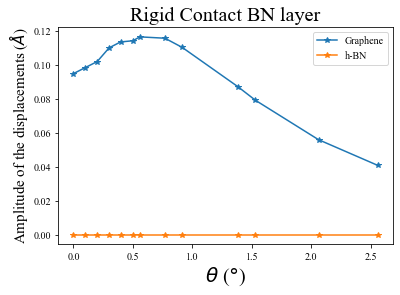

In [12]:
from scipy.interpolate import griddata
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = 'Times New Roman'

Ang = ['0.0','0.1','0.2','0.3','0.396','0.5','0.558','0.769','0.915','1.381','1.530','2.060','2.558']

angle = []
disp_top = []
disp_bottom = []
for ang in Ang:
    datadir = '../Ang'+ang+'/Band//'
    
    File = datadir+"generate.xyz"
    FileI = datadir+"generateInit.xyz"
    
    data = np.genfromtxt(File,skip_header=4)
    dataI = np.genfromtxt(FileI,skip_header=4)
    
    xdata = data[::2,1]
    ydata = data[::2,2]
    zdata = data[::2,3]
    
    xdataI = dataI[::2,1]
    ydataI = dataI[::2,2]
    zdataI = dataI[::2,3]
    
    cutoff = 10000
    
    xdataC = xdata[np.logical_and(xdata<cutoff, ydata<cutoff)]
    ydataC = ydata[np.logical_and(xdata<cutoff, ydata<cutoff)]
    zdataC = zdata[np.logical_and(xdata<cutoff, ydata<cutoff)]
    
    xdataIC = xdataI[np.logical_and(xdata<cutoff, ydata<cutoff)]
    ydataIC = ydataI[np.logical_and(xdata<cutoff, ydata<cutoff)]
    zdataIC = zdataI[np.logical_and(xdata<cutoff, ydata<cutoff)]
    
    xdataC_top = xdataC[zdataIC>17.5]
    ydataC_top = ydataC[zdataIC>17.5]
    zdataC_top = zdataC[zdataIC>17.5]
    
    xdataIC_top = xdataIC[zdataIC>17.5]
    ydataIC_top = ydataIC[zdataIC>17.5]
    zdataIC_top = zdataIC[zdataIC>17.5]
    
    displacementx_top = xdataC_top-xdataIC_top
    displacementy_top = ydataC_top-ydataIC_top
    displacementz_top = zdataC_top-zdataIC_top
    displacementxy_top = np.sqrt(((displacementx_top))**2 + ((displacementy_top))**2)
    displacementx_top = displacementx_top[(displacementxy_top)<=0.25] 
    displacementy_top = displacementy_top[(displacementxy_top)<=0.25] 
    xdataC_top = xdataC_top[(displacementxy_top)<=0.25] 
    ydataC_top = ydataC_top[(displacementxy_top)<=0.25] 
    displacementxy_top = displacementxy_top[(displacementxy_top)<=0.25] 
    
    xdataC_bottom = xdataC[zdataIC==15.825]
    ydataC_bottom = ydataC[zdataIC==15.825]
    zdataC_bottom = zdataC[zdataIC==15.825]
    
    xdataIC_bottom = xdataIC[zdataIC==15.825]
    ydataIC_bottom = ydataIC[zdataIC==15.825]
    zdataIC_bottom = zdataIC[zdataIC==15.825]
    
    displacementx_bottom = xdataC_bottom-xdataIC_bottom
    displacementy_bottom = ydataC_bottom-ydataIC_bottom
    displacementz_bottom = zdataC_bottom-zdataIC_bottom
    displacementxy_bottom = np.sqrt(((displacementx_bottom))**2 + ((displacementy_bottom))**2)
    displacementx_bottom = displacementx_bottom[(displacementxy_bottom)<=0.25] 
    displacementy_bottom = displacementy_bottom[(displacementxy_bottom)<=0.25] 
    xdataC_bottom = xdataC_bottom[(displacementxy_bottom)<=0.25] 
    ydataC_bottom = ydataC_bottom[(displacementxy_bottom)<=0.25] 
    displacementxy_bottom = displacementxy_bottom[(displacementxy_bottom)<=0.25] 
    
    Maxdisplacement_xy_top = max(displacementxy_top)
    #rint(ang, Maxdisplacement_xy_top)
    Maxdisplacement_xy_bottom = max(displacementxy_bottom)
    #rint(ang, Maxdisplacement_xy_bottom)
    angle.append(float(ang))
    disp_top.append(Maxdisplacement_xy_top)
    disp_bottom.append(Maxdisplacement_xy_bottom)
    
plt.plot(angle,disp_top,'-*',label='Graphene')
plt.plot(angle,disp_bottom,'-*',label='h-BN')

plt.title('Rigid Contact BN layer',fontsize=20)
#plt.xlabel('$\theta$ ($\degree$)',fontsize=20)
plt.xlabel(''r'$\theta$ ($\degree$)',fontsize=20)
plt.ylabel('Amplitude of the displacements ($\AA$)',fontsize=15)

plt.legend()
plt.savefig('FixBN.jpg',dpi=400)
    #im = plt.quiver(xdataC_top,ydataC_top,displacementx_top,displacementy_top)

0.09474490346700304
0.0
0.0
0.09830043730656532
0.0
0.0
0.10185646579409129
0.0
0.0
0.10992288532561892
0.0
0.0
0.11339823152264605
0.0
0.0
0.11409888256549182
0.0
0.0
0.11638798789305084
0.0
0.0
0.11559593711969247
0.0
0.0
0.11015846593741294
0.0
0.0
0.08712167929985237
0.0
0.0
0.07904711358504415
0.0
0.0
0.05585002372122759
0.0
0.0
0.04071127803008028
0.0
0.0


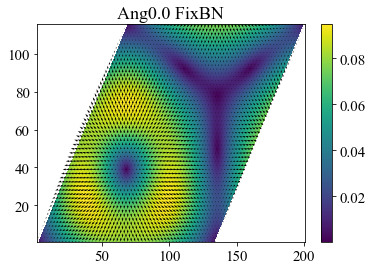

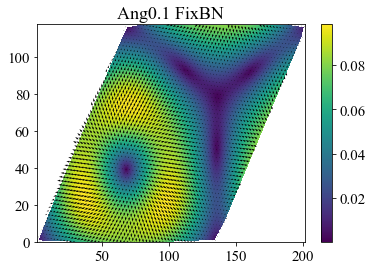

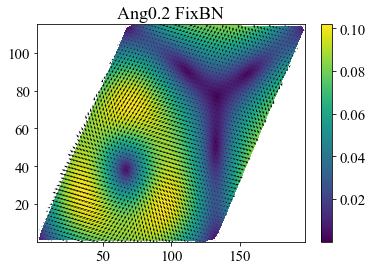

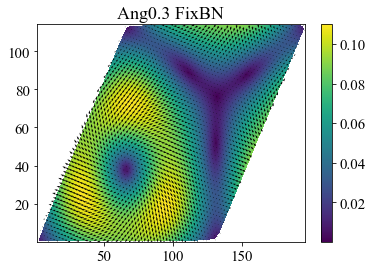

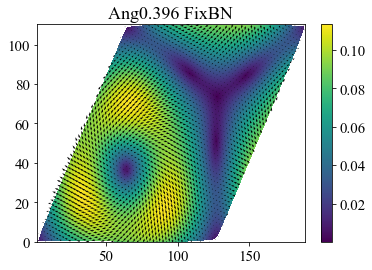

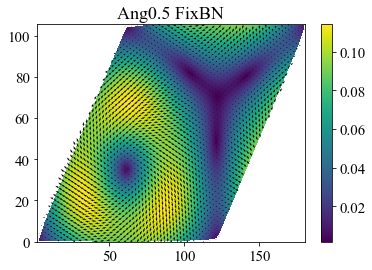

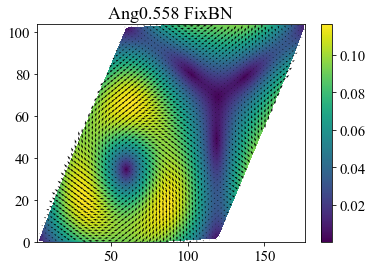

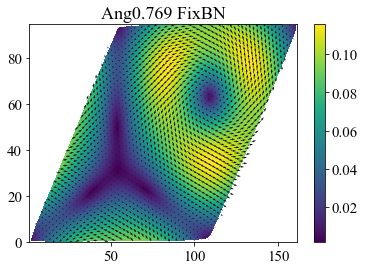

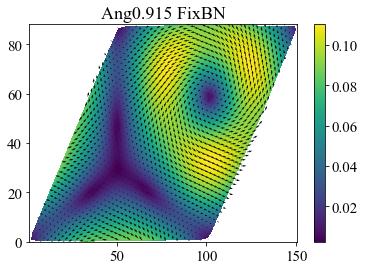

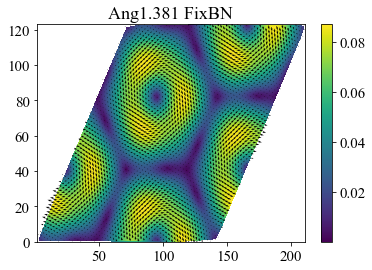

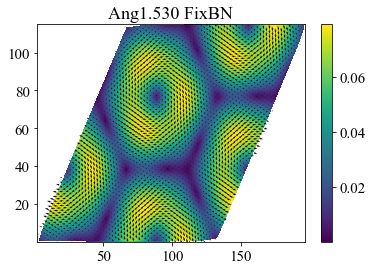

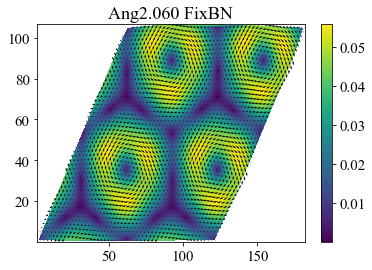

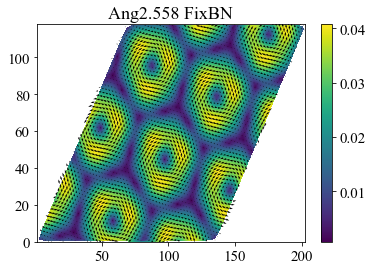

In [112]:
from scipy.interpolate import griddata
import numpy as np
import matplotlib.pyplot as plt

from scipy.interpolate import griddata
import numpy as np
import matplotlib.pyplot as plt

setLatex = False
from mpl_toolkits.axes_grid1 import make_axes_locatable

Ang = ['0.0','0.1','0.2','0.3','0.396','0.5','0.558','0.769','0.915','1.381','1.530','2.060','2.558']
Type = 'FixBN'

for ang1 in Ang:
    plt.figure()
    plt.rcParams['font.sans-serif'] = 'Times New Roman'
    plt.rcParams['font.size'] = 15
    
    datadir = '../Ang'+ang1+'/Band/'+Type+'/'

    File = datadir+"generate.xyz"
    FileI = datadir+"generateInit.xyz"

    data = np.genfromtxt(File,skip_header=4)
    dataI = np.genfromtxt(FileI,skip_header=4)


    #Lvec = np.genfromtxt(datadir+'unitVectors.dat')
    #print(Lvec)

    xdata = data[::2,1]
    ydata = data[::2,2]
    zdata = data[::2,3]

    xdataI = dataI[::2,1]
    ydataI = dataI[::2,2]
    zdataI = dataI[::2,3]

    cutoff = 10000

    xdataC = xdata[np.logical_and(xdata<cutoff, ydata<cutoff)]
    ydataC = ydata[np.logical_and(xdata<cutoff, ydata<cutoff)]
    zdataC = zdata[np.logical_and(xdata<cutoff, ydata<cutoff)]

    xdataIC = xdataI[np.logical_and(xdata<cutoff, ydata<cutoff)]
    ydataIC = ydataI[np.logical_and(xdata<cutoff, ydata<cutoff)]
    zdataIC = zdataI[np.logical_and(xdata<cutoff, ydata<cutoff)]

    xdataC_top = xdataC[zdataIC>17.5]
    ydataC_top = ydataC[zdataIC>17.5]
    zdataC_top = zdataC[zdataIC>17.5]

    xdataIC_top = xdataIC[zdataIC>17.5]
    ydataIC_top = ydataIC[zdataIC>17.5]
    zdataIC_top = zdataIC[zdataIC>17.5]

    displacementx_top = xdataC_top-xdataIC_top
    displacementy_top = ydataC_top-ydataIC_top
    displacementz_top = zdataC_top-zdataIC_top
    displacementxy_top = np.sqrt(((displacementx_top))**2 + ((displacementy_top))**2)
    displacementx_top = displacementx_top[(displacementxy_top)<=0.25] 
    displacementy_top = displacementy_top[(displacementxy_top)<=0.25] 
    xdataC_top = xdataC_top[(displacementxy_top)<=0.25] 
    ydataC_top = ydataC_top[(displacementxy_top)<=0.25] 
    displacementxy_top = displacementxy_top[(displacementxy_top)<=0.25] 


    xdataC_bottom = xdataC[zdataIC==15.825]
    ydataC_bottom = ydataC[zdataIC==15.825]
    zdataC_bottom = zdataC[zdataIC==15.825]

    xdataIC_bottom = xdataIC[zdataIC==15.825]
    ydataIC_bottom = ydataIC[zdataIC==15.825]
    zdataIC_bottom = zdataIC[zdataIC==15.825]

    displacementx_bottom = xdataC_bottom-xdataIC_bottom
    displacementy_bottom = ydataC_bottom-ydataIC_bottom
    displacementz_bottom = zdataC_bottom-zdataIC_bottom
    displacementxy_bottom = np.sqrt(((displacementx_bottom))**2 + ((displacementy_bottom))**2)
    displacementx_bottom = displacementx_bottom[(displacementxy_bottom)<=0.25] 
    displacementy_bottom = displacementy_bottom[(displacementxy_bottom)<=0.25] 
    xdataC_bottom = xdataC_bottom[(displacementxy_bottom)<=0.25] 
    ydataC_bottom = ydataC_bottom[(displacementxy_bottom)<=0.25] 
    displacementxy_bottom = displacementxy_bottom[(displacementxy_bottom)<=0.25] 

    Maxdisplacement_xy_top = max(displacementxy_top)
    print(Maxdisplacement_xy_top)
    Maxdisplacement_xy_bottom = max(displacementxy_bottom)
    print(Maxdisplacement_xy_bottom)

    num = 2000
    x = np.linspace(min(xdataIC_top),max(xdataIC_top),num)
    y = np.linspace(min(ydataIC_top),max(ydataIC_top),num)

    print(max(displacementxy_bottom))
    cmax = max(displacementxy_bottom)
    zdataDXInterpTop=griddata((xdataC_top,ydataC_top),displacementxy_top,(x[None,:], y[:,None]), method='linear')

    step = 1
    im = plt.quiver(xdataC_top[::step],ydataC_top[::step],displacementx_top[::step],displacementy_top[::step])
    im0 = plt.imshow(zdataDXInterpTop,origin="lower",aspect="auto",extent=[min(xdataC_top),max(xdataC_top),min(ydataC_top),max(ydataC_top)])#,vmin=0,vmax=0.07)
    cbar = plt.colorbar()

    plt.title("Ang"+ang1+" "+Type)
    plt.savefig("Ang"+ang1+" "+Type+".jpg",dpi=400,bbox_inches='tight')

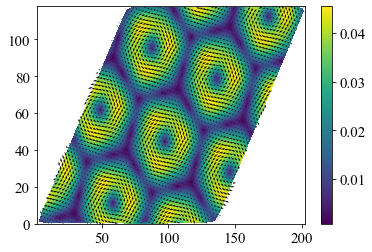

In [109]:
plt.rcParams['font.sans-serif'] = 'Times New Roman'
plt.rcParams['font.size'] = 15

im = plt.quiver(xdataC_top[::step],ydataC_top[::step],displacementx_top[::step],displacementy_top[::step])
im0 = plt.imshow(zdataDXInterpTop,origin="lower",aspect="auto",extent=[min(xdataC_top),max(xdataC_top),min(ydataC_top),max(ydataC_top)])#,vmin=0,vmax=0.07)
cbar = plt.colorbar()
#ticklabs = cbar.ax.get_yticklabels()
#cbar.ax.set_yticklabels(ticklabs, fontsize=10)

In [36]:
from scipy.interpolate import griddata
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = 'Times New Roman'

Ang = ['0.0','0.1','0.2','0.3','0.396','0.5','0.558','0.769','0.915','1.381','1.530','2.060','2.558']
Ang2 = ['3.0','4.0','5.0','7.5']
#Type = ['FixBN','Substrate','FullRelaxed','Rigid']
#Type  = ['Rigid','FullRelaxed','Substrate','FixBN']
Type  = ['FullRelaxed','Substrate','FixBN']
#Mtype  = ['s:','o-','^-.','*--']
#Msize  = [11,13,12,19]
Mtype  = ['o-','^-.','*--']
Msize  = [13,12,19]

for tp in Type:
    angle = []
    disp_top = []
    disp_bottom = []
    mmtype= Mtype[Type.index(tp)] 
    mmsize= Msize[Type.index(tp)] 
    for ang in Ang:
        datadir = '../Ang'+ang+'/Band/'+tp+'/'

        File = datadir+"generate.xyz"
        FileI = datadir+"generateInit.xyz"

        data = np.genfromtxt(File,skip_header=4)
        dataI = np.genfromtxt(FileI,skip_header=4)

        xdata = data[::2,1]
        ydata = data[::2,2]
        zdata = data[::2,3]

        xdataI = dataI[::2,1]
        ydataI = dataI[::2,2]
        zdataI = dataI[::2,3]

        cutoff = 10000

        xdataC = xdata[np.logical_and(xdata<cutoff, ydata<cutoff)]
        ydataC = ydata[np.logical_and(xdata<cutoff, ydata<cutoff)]
        zdataC = zdata[np.logical_and(xdata<cutoff, ydata<cutoff)]

        xdataIC = xdataI[np.logical_and(xdata<cutoff, ydata<cutoff)]
        ydataIC = ydataI[np.logical_and(xdata<cutoff, ydata<cutoff)]
        zdataIC = zdataI[np.logical_and(xdata<cutoff, ydata<cutoff)]

        xdataC_top = xdataC[zdataIC>17.5]
        ydataC_top = ydataC[zdataIC>17.5]
        zdataC_top = zdataC[zdataIC>17.5]

        xdataIC_top = xdataIC[zdataIC>17.5]
        ydataIC_top = ydataIC[zdataIC>17.5]
        zdataIC_top = zdataIC[zdataIC>17.5]

        displacementx_top = xdataC_top-xdataIC_top
        displacementy_top = ydataC_top-ydataIC_top
        displacementz_top = zdataC_top-zdataIC_top
        displacementxy_top = np.sqrt(((displacementx_top))**2 + ((displacementy_top))**2)
        displacementx_top = displacementx_top[(displacementxy_top)<=0.25] 
        displacementy_top = displacementy_top[(displacementxy_top)<=0.25] 
        xdataC_top = xdataC_top[(displacementxy_top)<=0.25] 
        ydataC_top = ydataC_top[(displacementxy_top)<=0.25] 
        displacementxy_top = displacementxy_top[(displacementxy_top)<=0.25] 

        xdataC_bottom = xdataC[zdataIC==15.825]
        ydataC_bottom = ydataC[zdataIC==15.825]
        zdataC_bottom = zdataC[zdataIC==15.825]

        xdataIC_bottom = xdataIC[zdataIC==15.825]
        ydataIC_bottom = ydataIC[zdataIC==15.825]
        zdataIC_bottom = zdataIC[zdataIC==15.825]

        displacementx_bottom = xdataC_bottom-xdataIC_bottom
        displacementy_bottom = ydataC_bottom-ydataIC_bottom
        displacementz_bottom = zdataC_bottom-zdataIC_bottom
        displacementxy_bottom = np.sqrt(((displacementx_bottom))**2 + ((displacementy_bottom))**2)
        displacementx_bottom = displacementx_bottom[(displacementxy_bottom)<=0.25] 
        displacementy_bottom = displacementy_bottom[(displacementxy_bottom)<=0.25] 
        xdataC_bottom = xdataC_bottom[(displacementxy_bottom)<=0.25] 
        ydataC_bottom = ydataC_bottom[(displacementxy_bottom)<=0.25] 
        displacementxy_bottom = displacementxy_bottom[(displacementxy_bottom)<=0.25] 

        Maxdisplacement_xy_top = max(displacementxy_top)
        #rint(ang, Maxdisplacement_xy_top)
        Maxdisplacement_xy_bottom = max(displacementxy_bottom)
        #rint(ang, Maxdisplacement_xy_bottom)
        angle.append(float(ang))
        disp_top.append(Maxdisplacement_xy_top)
        disp_bottom.append(Maxdisplacement_xy_bottom)
        
    for ang in Ang2:
        datadir = '../Ang'+ang+'/LAMMPS/'+tp+'/'

        File = datadir+"generate.xyz"
        FileI = datadir+"generateInit.xyz"

        data = np.genfromtxt(File,skip_header=4)
        dataI = np.genfromtxt(FileI,skip_header=4)

        xdata = data[::2,1]
        ydata = data[::2,2]
        zdata = data[::2,3]

        xdataI = dataI[::2,1]
        ydataI = dataI[::2,2]
        zdataI = dataI[::2,3]

        cutoff = 10000

        xdataC = xdata[np.logical_and(xdata<cutoff, ydata<cutoff)]
        ydataC = ydata[np.logical_and(xdata<cutoff, ydata<cutoff)]
        zdataC = zdata[np.logical_and(xdata<cutoff, ydata<cutoff)]

        xdataIC = xdataI[np.logical_and(xdata<cutoff, ydata<cutoff)]
        ydataIC = ydataI[np.logical_and(xdata<cutoff, ydata<cutoff)]
        zdataIC = zdataI[np.logical_and(xdata<cutoff, ydata<cutoff)]

        xdataC_top = xdataC[zdataIC>17.5]
        ydataC_top = ydataC[zdataIC>17.5]
        zdataC_top = zdataC[zdataIC>17.5]

        xdataIC_top = xdataIC[zdataIC>17.5]
        ydataIC_top = ydataIC[zdataIC>17.5]
        zdataIC_top = zdataIC[zdataIC>17.5]

        displacementx_top = xdataC_top-xdataIC_top
        displacementy_top = ydataC_top-ydataIC_top
        displacementz_top = zdataC_top-zdataIC_top
        displacementxy_top = np.sqrt(((displacementx_top))**2 + ((displacementy_top))**2)
        displacementx_top = displacementx_top[(displacementxy_top)<=0.25] 
        displacementy_top = displacementy_top[(displacementxy_top)<=0.25] 
        xdataC_top = xdataC_top[(displacementxy_top)<=0.25] 
        ydataC_top = ydataC_top[(displacementxy_top)<=0.25] 
        displacementxy_top = displacementxy_top[(displacementxy_top)<=0.25] 

        xdataC_bottom = xdataC[zdataIC==15.825]
        ydataC_bottom = ydataC[zdataIC==15.825]
        zdataC_bottom = zdataC[zdataIC==15.825]

        xdataIC_bottom = xdataIC[zdataIC==15.825]
        ydataIC_bottom = ydataIC[zdataIC==15.825]
        zdataIC_bottom = zdataIC[zdataIC==15.825]

        displacementx_bottom = xdataC_bottom-xdataIC_bottom
        displacementy_bottom = ydataC_bottom-ydataIC_bottom
        displacementz_bottom = zdataC_bottom-zdataIC_bottom
        displacementxy_bottom = np.sqrt(((displacementx_bottom))**2 + ((displacementy_bottom))**2)
        displacementx_bottom = displacementx_bottom[(displacementxy_bottom)<=0.25] 
        displacementy_bottom = displacementy_bottom[(displacementxy_bottom)<=0.25] 
        xdataC_bottom = xdataC_bottom[(displacementxy_bottom)<=0.25] 
        ydataC_bottom = ydataC_bottom[(displacementxy_bottom)<=0.25] 
        displacementxy_bottom = displacementxy_bottom[(displacementxy_bottom)<=0.25] 

        Maxdisplacement_xy_top = max(displacementxy_top)
        #rint(ang, Maxdisplacement_xy_top)
        Maxdisplacement_xy_bottom = max(displacementxy_bottom)
        #rint(ang, Maxdisplacement_xy_bottom)
        angle.append(float(ang))
        disp_top.append(Maxdisplacement_xy_top)
        disp_bottom.append(Maxdisplacement_xy_bottom)
        
    plt.plot(angle,disp_top,mmtype,color = 'C4',ms=mmsize,mec='w')
    plt.plot(angle,disp_bottom,mmtype,color = 'C3',ms=mmsize,mec='w')

#    if tp == 'FullRelaxed':
#        plt.plot(angle,disp_top,Mtype[1],color = 'C4')#,label='Graphene')
#        plt.plot(angle,disp_bottom,Mtype[1],color = 'C3')#,label='h-BN')
#    elif tp == 'Substrate':
#        plt.plot(angle,disp_top,Mtype[2],color = 'C4')#,label='Graphene')
#        plt.plot(angle,disp_bottom,Mtype[2],color = 'C3')#,label='h-BN')
#    elif tp == 'FixBN':
#        plt.plot(angle,disp_top,Mtype[3],color = 'C4')#,label='Graphene')
#        plt.plot(angle,disp_bottom,Mtype[3],color = 'C3')#,label='h-BN')

plt.xlim([0.0,3.0])
#plt.title('Rigid Contact BN layer',fontsize=20)
#plt.xlabel('$\theta$ ($\degree$)',fontsize=20)
plt.xlabel(''r'$\theta$ ($\degree$)',fontsize=20)
plt.ylabel('|'r'$\textbf{u}$| ($\AA$)',fontsize=15)

#plt.legend()
plt.savefig('All.jpg',dpi=400,bbox_inches='tight')
    #im = plt.quiver(xdataC_top,ydataC_top,displacementx_top,displacementy_top)

ValueError: 
\textbf{u}
^
Unknown symbol: \textbf, found '\'  (at char 0), (line:1, col:1)

ValueError: 
\textbf{u}
^
Unknown symbol: \textbf, found '\'  (at char 0), (line:1, col:1)

<Figure size 432x288 with 1 Axes>

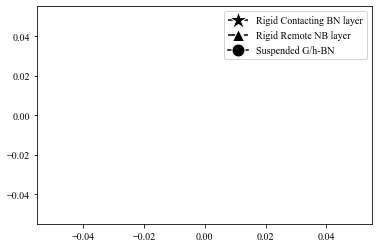

In [28]:
AA_r  = []
AB_r  = []
BA_r  = []
SP1_r = []
SP2_r = []
SP3_r = []
Ang   = []

Mtype  = ['s:','o-','^-.','*--']
Msize  = [11,13,12,19]

#plt.plot(Ang,SP1_r,Mtype[0],label="Rigid G/h-BN",ms=Msize[0],color='k',mec='w')
# plt.axhline(y=1./3.,lw=2.5,color='grey',linestyle=':',label="Rigid G/h-BN")
plt.plot(Ang,SP1_r,Mtype[3],label="Rigid Contacting BN layer",ms=Msize[3],color='k',mec='w')
plt.plot(Ang,SP1_r,Mtype[2],label="Rigid Remote NB layer",ms=Msize[2],color='k',mec='w')
plt.plot(Ang,SP1_r,Mtype[1],label="Suspended G/h-BN",ms=Msize[1],color='k',mec='w')

plt.legend()

plt.savefig('Temp.jpg',dpi=400,bbox_inches='tight')